# TP 3 — Pipeline complet : segmentation → mesures → classification

**Objectifs**

- Mettre en place un pipeline de bout en bout sur une image réelle.
- Extraire des features géométriques par objet via `regionprops`.
- Classifier chaque objet à partir de ses features.

**Durée indicative : 60 minutes.**

Text(0.5, 1.0, 'data.coins')

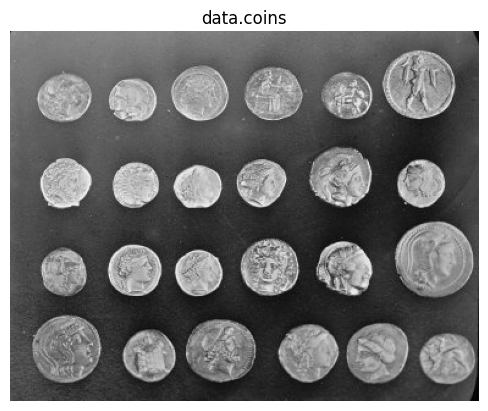

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import patches
from skimage import data, filters, measure, morphology
from sklearn.cluster import KMeans

coins = data.coins()
plt.imshow(coins, cmap="gray")
plt.axis("off")
plt.title("data.coins")

## Exercice 1 — Segmentation propre

Reconstituez le pipeline de segmentation vu au module 2 :

1. Seuillage Otsu → masque binaire.
2. Ouverture (disque rayon 2) pour enlever les petits points.
3. Fermeture (disque rayon 5) pour boucher les trous.
4. `measure.label` pour étiqueter les composantes.
5. Affichez l'image en niveaux de gris et superposez en transparence les contours des objets (vous pouvez utiliser `measure.find_contours`).

<details>
<summary>💡 Coup de pouce — pipeline segmentation propre</summary>

**🎯 But :** enchaîner Otsu + morphologie + étiquetage pour passer d'une photo brute à un masque exploitable.

**Pipeline standard**

```python
from skimage import data, filters
from skimage.morphology import opening, closing, disk
from skimage.measure import label

coins = data.coins()
t = filters.threshold_otsu(coins)
mask = coins > t                          # 1) Otsu
mask = opening(mask, disk(2))             # 2) enlève les petites taches
mask = closing(mask, disk(5))             # 3) bouche les trous
labels = label(mask)                       # 4) étiquette les composantes
print(f"{labels.max()} objets détectés")
```

**Pourquoi cet ordre exact ?**
1. **Otsu** trouve le seuil optimal automatiquement.
2. **Ouverture** d'abord (disque petit) : élimine le bruit isolé du fond.
3. **Fermeture** ensuite (disque plus gros) : bouche les trous internes (motifs gravés sur les pièces).
4. **Label** : assigne un id 1, 2, 3... à chaque blob connexe.

**Extraire les contours**

```python
from skimage import measure
contours = measure.find_contours(mask, 0.5)
```

`find_contours` retourne une **liste de tableaux**. Chaque tableau est de shape `(N_i, 2)` et contient les **coordonnées (row, col)** des points du contour.

`0.5` est le niveau d'iso-contour : pour un masque binaire, c'est la frontière entre les pixels à 0 et à 1.

**Afficher les contours en rouge**

```python
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(coins, cmap='gray')
for c in contours:
    ax.plot(c[:, 1], c[:, 0], 'r-', linewidth=1)   # ← attention à l'ordre
ax.axis('off')
```

⚠️ **L'inversion (col, row) → (x, y)** : `find_contours` renvoie `(row, col)` (= NumPy axis 0, axis 1). Matplotlib veut `(x, y)` (= colonne, ligne). Donc on plot `c[:, 1]` (colonnes) en x et `c[:, 0]` (lignes) en y.

</details>

In [2]:
# TODO


## Exercice 2 — Extraction de features par objet

Pour chaque composante connexe d'aire ≥ 200 pixels, construisez un vecteur de features :

- `area`,
- `perimeter`,
- `eccentricity`,
- `solidity`,
- `mean_intensity` (passez `intensity_image=coins` à `regionprops`).

Stockez le tout dans un tableau `X` de shape `(n_pieces, 5)`. Affichez les premières lignes.

<details>
<summary>💡 Coup de pouce — extraire des features par objet</summary>

**🎯 But :** mesurer pour chaque pièce un vecteur de caractéristiques (aire, périmètre, forme, intensité) pour classer ensuite.

**`regionprops` avec image source**

```python
from skimage.measure import regionprops
regions = regionprops(labels, intensity_image=coins)
```

⚠️ Passer `intensity_image=coins` (l'image originale, pas le masque) permet d'accéder à `region.mean_intensity` et `region.max_intensity`. Sans cet argument, ces propriétés ne sont pas calculées.

**Filtrer les petits artefacts**

```python
regions = [r for r in regions if r.area >= 200]
print(f"{len(regions)} pièces après filtrage")
```

200 pixels² est un seuil empirique pour la taille des pièces. Adaptez selon votre image.

**Construire la matrice de features**

```python
import numpy as np
X = np.array([
    [r.area, r.perimeter, r.eccentricity, r.solidity, r.mean_intensity]
    for r in regions
])
# Shape (n_pieces, 5)
```

**Sens de chaque feature**

| Feature | Interprétation |
|---|---|
| `area` | nombre de pixels dans la région (= taille) |
| `perimeter` | longueur du contour |
| `eccentricity` | 0 = cercle parfait, 1 = ligne |
| `solidity` | aire / aire du convex hull (1 = forme convexe) |
| `mean_intensity` | brillance moyenne des pixels de la région |

Pour des pièces de monnaie circulaires, vous devriez voir : `eccentricity` proche de 0, `solidity` proche de 1.

**Cas typique sur `coins`**

- **Petites pièces** vs **grosses pièces** : différenciables par `area`.
- **Pièces sombres** vs **claires** : par `mean_intensity`.
- → Idéal pour classer en 2 catégories par k-means en Exo 3.

</details>

In [3]:
# TODO


## Exercice 3 — Classification non supervisée par taille

Sans étiquettes, on suppose qu'il existe deux tailles de pièces sur l'image. On va les regrouper avec k-means.

1. Appliquez `KMeans(n_clusters=2, n_init=10, random_state=0)` sur les colonnes `[area, perimeter]` standardisées.
2. Récupérez les labels.
3. Tracez sur l'image originale les bounding boxes en couleur différente selon le cluster (utilisez `matplotlib.patches.Rectangle`).
4. Comptez combien de pièces dans chaque groupe.

<details>
<summary>💡 Coup de pouce — classification non supervisée par taille</summary>

**🎯 But :** appliquer k-means sur les features extraites pour séparer automatiquement les pièces en 2 groupes (petites vs grosses, par exemple).

**Préparer les données**

On garde seulement 2 features pour visualiser facilement (par exemple `area` et `eccentricity`) :

```python
from sklearn.preprocessing import StandardScaler
X2 = StandardScaler().fit_transform(X[:, :2])   # n × 2
```

⚠️ **Standardiser est crucial**. Sans ça, l'`area` (échelle 200-3000) écrase l'`eccentricity` (échelle 0-1) → k-means clusterise quasi exclusivement par area.

**Appliquer k-means**

```python
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2, n_init=10, random_state=0)
clusters = km.fit_predict(X2)
```

`clusters` est un tableau `(n_pieces,)` avec valeurs 0 ou 1 = id du cluster.

**Annoter les bbox sur l'image originale**

```python
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(coins, cmap='gray')
colors = ['red', 'blue']
for r, cluster in zip(regions, clusters):
    minr, minc, maxr, maxc = r.bbox             # convention (row, col)
    rect = Rectangle((minc, minr), maxc - minc, maxr - minr,
                     fill=False, edgecolor=colors[cluster], linewidth=2)
    ax.add_patch(rect)
ax.axis('off')
```

⚠️ **`r.bbox` renvoie `(minr, minc, maxr, maxc)`** (lignes, colonnes), mais `Rectangle((x, y), w, h)` veut `(x, y) = (colonne, ligne)`. Conversion : `(minc, minr)` pour la position, `(maxc - minc, maxr - minr)` pour la taille.

**Ce que vous devriez voir**

Deux couleurs sur les pièces : rouge pour un groupe (par exemple petites pièces sombres), bleu pour l'autre (grosses pièces claires). C'est de la **classification non supervisée** : k-means a deviné le regroupement sans aucun label.

</details>

In [4]:
# TODO


## Exercice 4 — Diagramme de dispersion des features

Tracez un scatter `area` vs `eccentricity`, coloré par le cluster trouvé. Annotez chaque point avec son numéro de pièce. Vous devriez voir nettement deux groupes.

<details>
<summary>💡 Coup de pouce — diagramme de dispersion des features</summary>

**🎯 But :** vérifier visuellement que les pièces forment bien 2 nuages dans l'espace `(area, eccentricity)`.

**Scatter coloré par cluster**

```python
labels_kmeans = clusters     # depuis l'exo précédent
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='tab10', s=100)
plt.xlabel('area')
plt.ylabel('eccentricity')
plt.colorbar(label='cluster')
```

⚠️ Note : on plot avec `X` (non standardisé) pour avoir des **axes lisibles** (aire en px², eccentricité en [0, 1]). Le scaling était uniquement pour k-means.

**Annoter chaque point avec son numéro**

```python
for i, (a, e) in enumerate(zip(X[:, 0], X[:, 1])):
    plt.annotate(str(i), (a, e), fontsize=8, xytext=(5, 5), textcoords='offset points')
```

`xytext=(5, 5), textcoords='offset points'` décale le texte de 5 px en haut à droite → le numéro ne recouvre pas le point.

**Lecture attendue**

Vous devriez voir **2 nuages bien séparés** sur l'axe `area` (l'eccentricity est secondaire pour des pièces toutes rondes). Si les nuages se chevauchent fortement, le clustering 2 est sous-optimal → essayer 3 clusters ou une autre paire de features.

**Diagnostic du clustering**

| Pattern visuel | Diagnostic |
|---|---|
| 2 nuages bien séparés | k-means a trouvé une structure réelle |
| Un seul gros nuage | Pas vraiment 2 groupes → reconsidérer n_clusters |
| 3+ sous-nuages | Augmenter n_clusters ou utiliser silhouette pour choisir |

**Astuce — projection 2D si X a > 2 dimensions**

Si vous avez gardé toutes les features (`X` de shape `(n, 5)`), réduisez en 2D avec PCA pour visualiser :

```python
from sklearn.decomposition import PCA
X_2d = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_kmeans, cmap='tab10')
```

</details>

In [5]:
# TODO
